<a href="https://colab.research.google.com/github/Syauqitabuy1/electric-vehicle-analysis/blob/main/Exploratory_Data_Analysis_of_Electric_Vehicles_in_Washington.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT DATA CSV dan LIBRARY

In [14]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data (1).csv


In [15]:
import matplotlib.pyplot as plt
import numpy as np

In [16]:
data = pd.read_csv("Electric_Vehicle_Population_Data.csv")

In [17]:
print(data)

        VIN (1-10)     County               City State  Postal Code  \
0       WBY2Z2C57G     Yakima             Yakima    WA      98908.0   
1       5YJYGDEE8M     Yakima              Selah    WA      98942.0   
2       JTDKN3DP9D  Snohomish         Marysville    WA      98271.0   
3       WP1AE2AY6M     Yakima             Yakima    WA      98908.0   
4       LPSED3KA5M     Kitsap  Bainbridge Island    WA      98110.0   
...            ...        ...                ...   ...          ...   
285817  7FCTGBAA7S       King           Kirkland    WA      98033.0   
285818  7SAXCAE5XR     Kitsap         Silverdale    WA      98383.0   
285819  1C4RJYD67P       King          Covington    WA      98042.0   
285820  7PDSGABL0P  Snohomish            Edmonds    WA      98026.0   
285821  7SAYGDEE1S   Thurston            Olympia    WA      98502.0   

        Model Year      Make           Model  \
0             2016       BMW              I8   
1             2021     TESLA         MODEL Y   
2  

# **MENGENAL DATASET/EXPLORATORY DATA ANALYSIS (EDA)**

## Mencari tahu mobil yang mendominasi Washington

In [18]:
modus = data["Model Year"].mode()[0]
jumlah = data["Model Year"].value_counts()[modus]
print(f"Mobil yang mendominasi Washington adalah mobil keluaran tahun {modus},yakni sebanyak {jumlah} mobil.")

modus = data["Make"].mode()[0]
jumlah = data["Make"].value_counts()[modus]
print(f"Mobil yang mendominasi washington adalah mobil {modus},yakni sebanyak {jumlah} mobil.")

print(data["Make"].value_counts(1))

paling_sedikit = data["Make"].value_counts().idxmin()
jumlah_terendah = data["Make"].value_counts()[paling_sedikit]
print(f"Brand mobil yang paling sedikit muncul di Washington adalah {paling_sedikit}, yakni hanya sebanyak {jumlah_terendah} mobil.")

jumlah = data["Make"].value_counts()
merkcumasatu = jumlah[jumlah == 1]
print(f"Selain {paling_sedikit}, {merkcumasatu} juga merupakan brand yang kurang diminati di Washington")

Mobil yang mendominasi Washington adalah mobil keluaran tahun 2023,yakni sebanyak 60887 mobil.
Mobil yang mendominasi washington adalah mobil TESLA,yakni sebanyak 117392 mobil.
Make
TESLA                     0.410717
CHEVROLET                 0.068844
NISSAN                    0.056402
FORD                      0.054716
KIA                       0.050129
TOYOTA                    0.042803
BMW                       0.040893
HYUNDAI                   0.038720
RIVIAN                    0.031831
VOLKSWAGEN                0.026793
VOLVO                     0.026398
JEEP                      0.022920
AUDI                      0.020971
CHRYSLER                  0.012861
MERCEDES-BENZ             0.011885
HONDA                     0.011283
SUBARU                    0.010542
CADILLAC                  0.009079
PORSCHE                   0.007179
LEXUS                     0.006235
POLESTAR                  0.005822
MAZDA                     0.005503
MITSUBISHI                0.004524
MINI         

## Mengetahui jumlah mobil setiap brand yang terdaftar, tahun keluarannya, dan rata-rata jarak terjauh yang dapat ditempuh.

In [19]:
system = input("Enter your brand: ")

hasil = data[data['Make'] == system]

if not hasil.empty:
  print(hasil[["Make","Model Year", "Electric Range"]])
  elecrange = hasil["Electric Range"].mean()
  jumlah_brand = len(hasil)
  print(f"Jumlah mobil untuk brand {system} adalah sebanyak {jumlah_brand}")
  print(f"Rata-rata jarak terjauh yang dapat ditempuh {system} adalah {elecrange}")
else:
  print(f"{system} not found")

Enter your brand: TESLA
         Make  Model Year  Electric Range
1       TESLA        2021             0.0
5       TESLA        2018           215.0
21      TESLA        2020           322.0
23      TESLA        2018           215.0
24      TESLA        2020           293.0
...       ...         ...             ...
285813  TESLA        2023             0.0
285814  TESLA        2023             0.0
285816  TESLA        2019           220.0
285818  TESLA        2024             0.0
285821  TESLA        2025             0.0

[117392 rows x 3 columns]
Jumlah mobil untuk brand TESLA adalah sebanyak 117392
Rata-rata jarak terjauh yang dapat ditempuh TESLA adalah 49.89535913861251


## Rata-rata jarak tempuh terjauh tiap brand

In [20]:
hasil_group = data.groupby("Make").agg({
    "Electric Range": "mean",
    "Model Year": "min",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility":lambda x: x.mode()[0]
})

hasil_group.columns = [
    "Mean Electric Range",
    "Min Model Year",
    "CAFV Eligibility Status"
]

print(hasil_group)

                        Mean Electric Range  Min Model Year  \
Make                                                          
ACURA                              0.000000            2024   
ALFA ROMEO                        33.000000            2024   
ASTON MARTIN                       6.000000            2026   
AUDI                              36.402402            2016   
AZURE DYNAMICS                    56.000000            2011   
BENTLEY                           31.111111            2021   
BMW                               26.753593            2014   
BRIGHTDROP                         0.000000            2023   
CADILLAC                           1.191137            2014   
CHEVROLET                         75.839864            2011   
CHRYSLER                          32.171382            2017   
DODGE                             27.450602            2024   
FIAT                              73.589894            2013   
FISKER                             2.869565            

                      Mean Electric Range  Min Model Year
Make                                                     
ALFA ROMEO                      33.000000            2024
ASTON MARTIN                     6.000000            2026
AUDI                            36.402402            2016
AZURE DYNAMICS                  56.000000            2011
BENTLEY                         31.111111            2021
BMW                             26.753593            2014
CADILLAC                         1.191137            2014
CHEVROLET                       75.839864            2011
CHRYSLER                        32.171382            2017
DODGE                           27.450602            2024
FIAT                            73.589894            2013
FISKER                           2.869565            2012
FORD                             7.012405            1999
HONDA                           12.329922            2014
HYUNDAI                         11.038402            2016
JAGUAR        

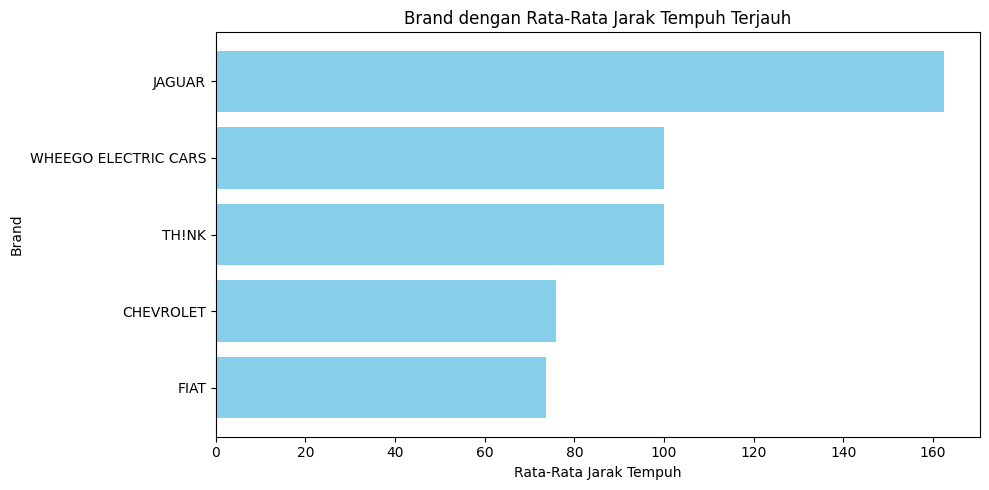

JAGUAR memiliki rata-rata jarak tempuh terjauh, yakni sebesar 162.37 mil


In [21]:
""" Washington State Department of Licensing (DOL) belum mencatat
jarak tempuh terjauh untuk semua mobil keluaran tahun 2024 ke atas.
Oleh karena itu, sementara brand yang sudah lengkap diuji adalah sebagai berikut"""

make_eligible = hasil_group[hasil_group["Mean Electric Range"]>0]
print(make_eligible[["Mean Electric Range","Min Model Year"]])

top_5_range = make_eligible["Mean Electric Range"].sort_values(ascending=False).head(5)
top_5_visual = top_5_range.sort_values(ascending=True)

y = top_5_visual.values
x = top_5_visual.index


plt.figure(figsize=(10, 5))
plt.barh(x, y, color = "skyblue")
plt.title("Brand dengan Rata-Rata Jarak Tempuh Terjauh")
plt.xlabel("Rata-Rata Jarak Tempuh")
plt.ylabel("Brand")
plt.tight_layout()

plt.show()

terjauh = make_eligible["Mean Electric Range"].idxmax()
nilaiterjauh = make_eligible["Mean Electric Range"].max()
print(f"{terjauh} memiliki rata-rata jarak tempuh terjauh, yakni sebesar {nilaiterjauh:.2f} mil")

## Mencari jumlah mobil berdasarkan daerah

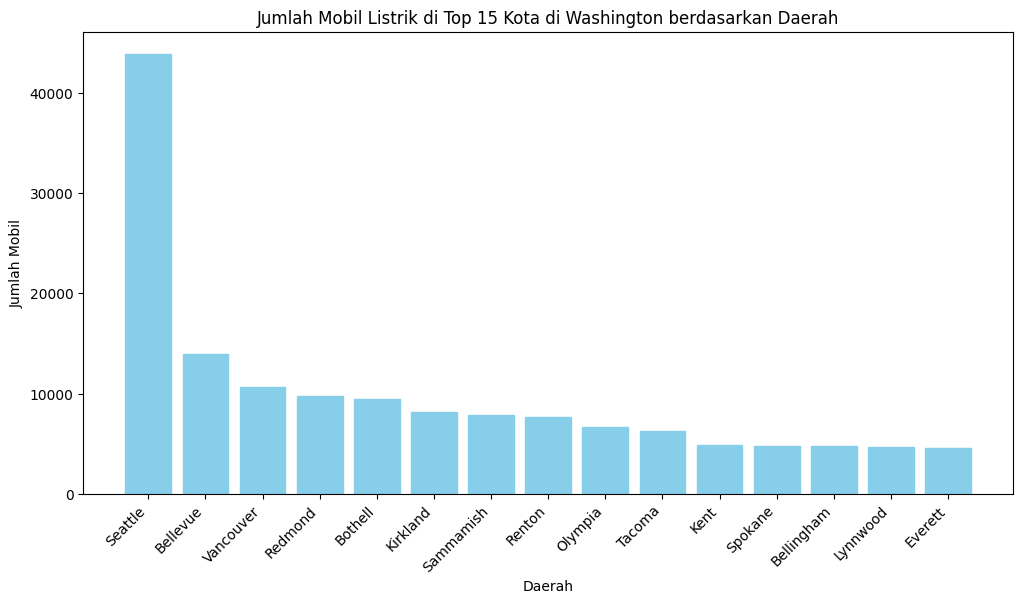

In [22]:
citycar = data.groupby("City").size()
top_cities = citycar.sort_values(ascending=False).head(15)


plt.figure(figsize=(12, 6))
plt.bar(top_cities.index,top_cities.values, color= "skyblue",
                                            edgecolor = "skyblue")

plt.title ("Jumlah Mobil Listrik di Top 15 Kota di Washington berdasarkan Daerah")
plt.xlabel("Daerah")
plt.ylabel("Jumlah Mobil")
plt.xticks (rotation=45, ha="right")
plt.show()

## Perbandingan tipe mobil listrik

Electric Vehicle Type
Battery Electric Vehicle (BEV)            80.426279
Plug-in Hybrid Electric Vehicle (PHEV)    19.573721
Name: proportion, dtype: float64


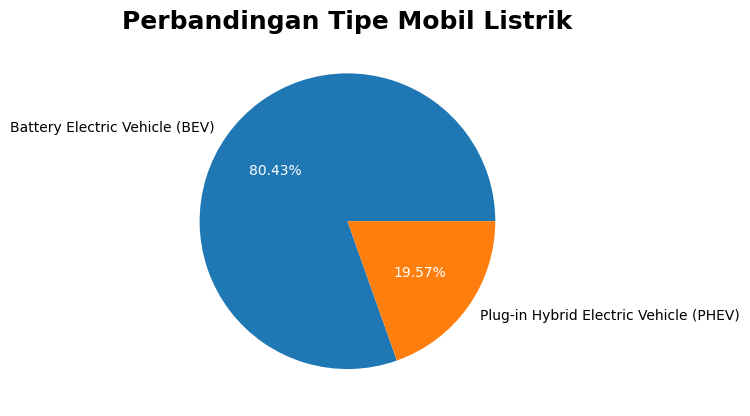

In [23]:
print(data["Electric Vehicle Type"].value_counts(normalize=True) * 100)
types = data.groupby("Electric Vehicle Type").size()
wedges, texts, autotexts = plt.pie(types.values, labels = types.index,
                      autopct = "%1.2f%%",
                      colors=["#1f77b4", "#ff7f0e"])
for a_text in autotexts:
  a_text.set_color("white")

plt.title ("Perbandingan Tipe Mobil Listrik",
           fontsize = 18,
           fontweight = "bold")
plt.show()
#Jenis BEV lebih banyak digunakan dibandingkan dengan PHEV karena memiliki proposi 80%.

## Mencari mobil keluaran tahun berapa saja yang ada di Washington

Model Year
1999        2
2000        7
2002        1
2003        1
2008       18
2010       22
2011      559
2012     1352
2013     3900
2014     3160
2015     4411
2016     5057
2017     8383
2018    13999
2019    10790
2020    12080
2021    20815
2022    30225
2023    60887
2024    49898
2025    37011
2026    23180
2027       64
dtype: int64


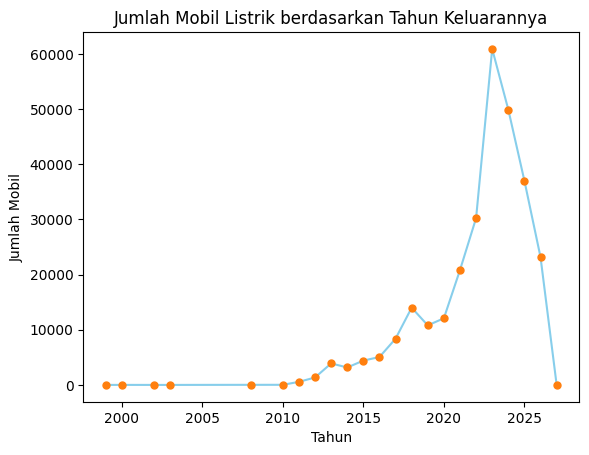

In [24]:
print(data.groupby("Model Year").size())


tahun = data.groupby("Model Year").size()
plt.plot(tahun.index,tahun.values, color = "skyblue",
                                  marker = ".",
                                  markersize = 10,
                                  markerfacecolor = "#ff7f0e",
                                  markeredgecolor = "#ff7f0e",
                                  linestyle = "solid")
plt.title("Jumlah Mobil Listrik berdasarkan Tahun Keluarannya")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Mobil")
plt.show()

## Perusahaan Listrik mana yang memegang beban paling besar untuk charging EV di wilayah tersebut


In [25]:
chargingcorp = data.groupby("County").agg({
    "Electric Utility": lambda x: x.value_counts().idxmax() if not x.dropna().empty else "No Data",
    "Model Year": lambda x: x.value_counts().max() if not x.dropna().empty else 0,
    "VIN (1-10)": "size"
})

chargingcorp.columns = ["Top Electric Utility", "Cars Handled by Top Utility", "Total Car"]

print(chargingcorp)

                                        Top Electric Utility  \
County                                                         
Ada                    NON WASHINGTON STATE ELECTRIC UTILITY   
Adams      BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...   
Alachua                NON WASHINGTON STATE ELECTRIC UTILITY   
Alameda                NON WASHINGTON STATE ELECTRIC UTILITY   
Albemarle              NON WASHINGTON STATE ELECTRIC UTILITY   
...                                                      ...   
Yakima                                            PACIFICORP   
Yavapai                NON WASHINGTON STATE ELECTRIC UTILITY   
York                   NON WASHINGTON STATE ELECTRIC UTILITY   
Yuba                   NON WASHINGTON STATE ELECTRIC UTILITY   
Yuma                   NON WASHINGTON STATE ELECTRIC UTILITY   

           Cars Handled by Top Utility  Total Car  
County                                             
Ada                                  1          2  
Adams      